In [1]:
import xarray as xr
import geopandas as gp
import regionmask
import cartopy
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib import colors as mplc
import numpy as np

## Shapefile

In [2]:
gdf = gp.read_file('grids.shp')

In [3]:
gdf

,grid,geometry
0,NEM_2030,"MULTIPOLYGON Z (((146.12455 -41.09714 0, 146.3..."
1,SE_2030,"MULTIPOLYGON Z (((143.39392 -37.77456 0, 143.6..."
2,NWIS,None
3,SWIS,None


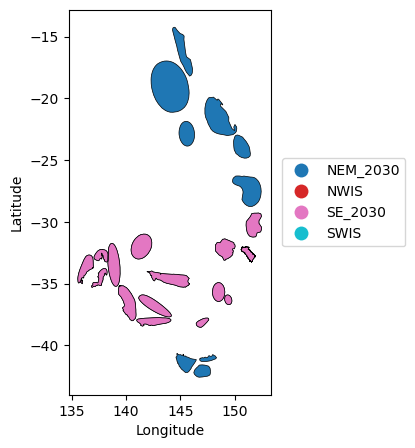

In [4]:
gdf.plot(
    figsize=[5, 5],
    column='grid',
    cmap='tab10',
    legend=True,
    linewidth=0.5,
    edgecolor='black',
    legend_kwds={'loc': 'right', 'bbox_to_anchor': (1.7, 0.5)},
)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

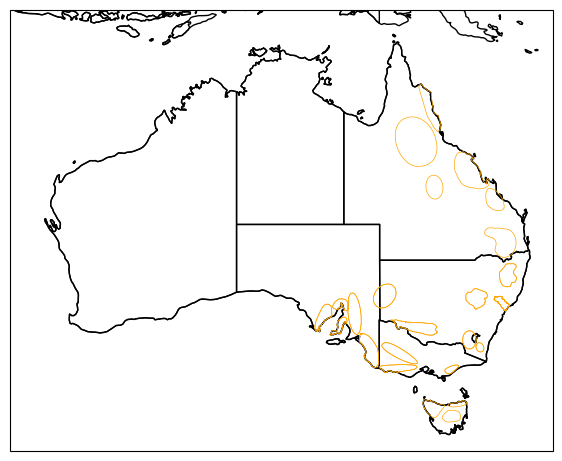

In [5]:
fig = plt.figure(figsize=[7, 7])
ax1 = fig.add_subplot(111, projection=ccrs.PlateCarree())
ax1.coastlines()
ax1.add_feature(cartopy.feature.STATES)
ax1.add_geometries(gdf[0:2].geometry, ccrs.PlateCarree(), facecolor='none', linewidth=0.5, edgecolor='orange')
ax1.set_extent([110, 155.5, -8, -45], crs=ccrs.PlateCarree())
plt.show()

## DCPP data

In [6]:
infile_highres = 'sfcWind_day_EC-Earth3_dcppA-hindcast_s1990-r1i1p1f1_gr_19901101-19911031.nc'
infile_lowres = 'sfcWind_day_CanESM5_dcppA-hindcast_s1990-r1i1p2f1_gn_19910101-20001231.nc'

In [7]:
ds_highres = xr.open_dataset(infile_highres)

In [8]:
#ds_highres